# 03 Income finale: combining volume and price

The two outcomes are not independent stories — they multiply into the quantity that actually matters to a farmer, **revenue**. They combine on an exact identity:

$$\log(\text{income}) = \log(\text{quantity}) + \log(\text{price})$$

This notebook estimates **nothing new**. The causal work is already done in `01_data` (volume) and `02_price` (price); here we simply **recombine** their per-country synthetic-control effects on that identity. The key property is that the identity holds **country by country**: each effect is a country's own deviation from its own counterfactual, so the fact that the two analyses used *different control sets* (the UK and others absent from price; Ireland dropped from quantity) does not matter — only the treated countries present in **both** valid sets enter.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROC = Path("data/processed")
CUTOFF = pd.Timestamp("2015-04-01")

## 1. Load the two effect sets

Each file is the per-country, per-month synthetic-control gap (treated − synthetic, in logs) from its analysis, restricted to the valid set that passed the pre-RMSPE cut. Income is defined only on the **intersection** of treated countries present in both.

In [2]:
gaps_quantity = pd.read_parquet(PROC / "gaps_quantity.parquet")
gaps_price    = pd.read_parquet(PROC / "gaps_price.parquet")

countries = sorted(set(gaps_quantity.columns) & set(gaps_price.columns))
dropped = sorted((set(gaps_quantity.columns) | set(gaps_price.columns)) - set(countries))
print("income countries:", countries, f"({len(countries)})")
print("dropped (not in both valid sets):", dropped or "none")

income countries: ['AT', 'BE', 'CY', 'DE', 'DK', 'EE', 'ES', 'IT', 'LU', 'NL', 'PL'] (11)
dropped (not in both valid sets): ['IE']


## 2. The decomposition

Because income is the *product* of quantity and price, its synthetic-control counterfactual is the product of the two outcome counterfactuals, and the gaps **add exactly in logs**:

$$\text{gap}_{\text{income}} = \text{gap}_{\text{quantity}} + \text{gap}_{\text{price}}$$

We average each over the post-period, restricted to the months where **both** outcomes are observed, so the identity holds exactly in the table (Luxembourg, for instance, has no 2019 price, so those months drop from all three columns together).

**One interpretive guard, stated up front.** The price column is a *statistical null* — four methods agreed there is no robust treated-vs-control price differential, and the small per-country price entries (especially Cyprus's) are fit noise, not a genuine relative price gain. So the income effect should be read as **driven by volume**, with the price contribution ≈ 0 within noise. We show the decomposition because the arithmetic is exact and honest; we do not oversell the price column as a real bonus.

In [3]:
# Restrict to months where both outcomes are observed, so income = quantity + price exactly.
gq, gp = gaps_quantity[countries], gaps_price[countries]
both = gq.notna() & gp.notna()
gq, gp = gq.where(both), gp.where(both)
gi = gq + gp

post = lambda g: g[g.index >= CUTOFF].mean()      # per-country post-period mean
table = pd.DataFrame({"quantity": post(gq), "price": post(gp), "income": post(gi)})
table = table.sort_values("income", ascending=False)

table_pct = (np.exp(table) - 1) * 100            # log gaps -> % for readability

print("Per-country effect (log points):")
print(table.round(3))
print("\nPer-country effect (%):")
print(table_pct.round(1))
print("\nAverage across countries (%):")
print(table_pct.mean().round(1))

Per-country effect (log points):
    quantity  price  income
CY     0.224  0.193   0.417
PL     0.089  0.065   0.153
AT     0.054  0.076   0.129
NL     0.106  0.019   0.125
BE     0.095  0.005   0.100
IT     0.047  0.043   0.090
DK     0.057  0.025   0.083
LU     0.036  0.044   0.080
DE     0.041  0.017   0.058
ES     0.035  0.003   0.038
EE    -0.014 -0.003  -0.017

Per-country effect (%):
    quantity  price  income
CY      25.1   21.3    51.7
PL       9.3    6.7    16.6
AT       5.5    7.9    13.8
NL      11.2    1.9    13.3
BE      10.0    0.5    10.5
IT       4.8    4.4     9.4
DK       5.9    2.5     8.6
LU       3.7    4.5     8.4
DE       4.1    1.7     6.0
ES       3.6    0.3     3.8
EE      -1.4   -0.3    -1.7

Average across countries (%):
quantity     7.4
price        4.7
income      12.8
dtype: float64


In [4]:
# Two corrections for an honest decomposition:
# (1) Drop Cyprus: worst-fit unit in BOTH analyses, so its +51.7% income is a
#     compounded fit artefact, not an effect.
# (2) De-bias each gap by its own pre-period level. The price synthetic carries a
#     small positive level bias visible already before 2015 (the differential is
#     a four-method null), so the true effect is post minus pre, not raw post.
PRE_END = pd.Timestamp("2014-12-01")
keep = [c for c in countries if c != "CY"]

def effect(g):
    g = g[keep]
    return g[g.index >= CUTOFF].mean() - g[g.index <= PRE_END].mean()

eff = pd.DataFrame({"quantity": effect(gq), "price": effect(gp), "income": effect(gi)})
eff = eff.sort_values("income", ascending=False)
eff_pct = (np.exp(eff) - 1) * 100

print("De-biased per-country effect (%), Cyprus excluded:")
print(eff_pct.round(1))
print("\nAverage across countries (%):")
print(eff_pct.mean().round(1))

De-biased per-country effect (%), Cyprus excluded:
    quantity  price  income
PL       9.3    6.7    16.6
AT       5.5    6.4    12.3
NL      10.5    0.7    11.3
BE      10.0   -0.8     9.1
IT       4.2    3.1     7.4
DK       5.3    2.0     7.4
LU       3.7    2.8     6.5
ES       3.5    1.6     5.2
EE       6.0   -0.8     5.2
DE       4.1    0.6     4.7

Average across countries (%):
quantity    6.2
price       2.2
income      8.6
dtype: float64


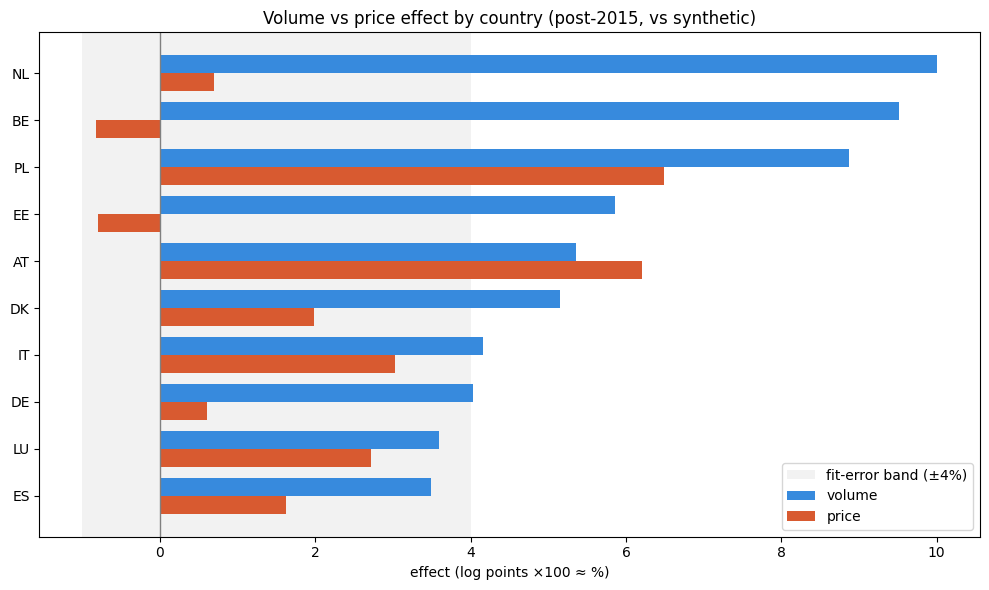

In [12]:
# Grouped bars: volume vs price side by side. The grey band marks the ~fit-error
# magnitude (pre-RMSPE ~0.04 ≈ 4%): price bars fall mostly inside it (noise),
# while volume bars clear it (a real effect).
order = eff.sort_values("quantity", ascending=True).index
y = np.arange(len(order)); h = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
ax.axvspan(-1, 4, color="grey", alpha=0.10, lw=0, zorder=0,
           label="fit-error band (±4%)")
ax.barh(y + h/2, eff.loc[order, "quantity"] * 100, height=h,
        color="#378ADD", label="volume")
ax.barh(y - h/2, eff.loc[order, "price"] * 100, height=h,
        color="#D85A30", label="price")
ax.axvline(0, color="grey", lw=1)
ax.set_yticks(y); ax.set_yticklabels(order)
ax.set(title="Volume vs price effect by country (post-2015, vs synthetic)",
       xlabel="effect (log points ×100 ≈ %)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

In [14]:
# Period-average vs 2019-endpoint effects, both de-biased by each country's own
# pre-2015 level, Cyprus excluded. The effect grows over time, so the 2019
# endpoint exceeds the period average — the same endpoint-vs-average distinction
# reconciled in the volume analysis (+11% endpoint vs ~+6% period mean).
PRE_END = pd.Timestamp("2014-12-01")
keep = [c for c in countries if c != "CY"]

def debiased(g, win):
    g = g[keep]
    return g[win(g.index)].mean() - g[g.index <= PRE_END].mean()

period  = lambda idx: idx >= CUTOFF
end2019 = lambda idx: idx.year == 2019

summary = pd.DataFrame({
    "volume_avg": debiased(gq, period),  "volume_2019": debiased(gq, end2019),
    "price_avg":  debiased(gp, period),  "price_2019":  debiased(gp, end2019),
    "income_avg": debiased(gi, period),  "income_2019": debiased(gi, end2019),
})
summary_pct = (np.exp(summary) - 1) * 100

# Two headline summaries side by side (cross-country averages).
head = pd.DataFrame({
    "period avg (2015-19)": summary_pct[["volume_avg", "price_avg", "income_avg"]].mean().values,
    "2019 endpoint":        summary_pct[["volume_2019", "price_2019", "income_2019"]].mean().values,
}, index=["volume", "price", "income"]).round(1)

print("Headline effects (%):")
print(head)
print("\nPer-country (%):")
print(summary_pct.round(1))

Headline effects (%):
        period avg (2015-19)  2019 endpoint
volume                   6.2            8.3
price                    2.2            1.0
income                   8.6            9.3

Per-country (%):
    volume_avg  volume_2019  price_avg  price_2019  income_avg  income_2019
AT         5.5          6.7        6.4         5.6        12.3         12.7
BE        10.0         15.9       -0.8        -1.6         9.1         14.1
DE         4.1          2.6        0.6         0.1         4.7          2.7
DK         5.3          7.0        2.0        -2.6         7.4          4.3
EE         6.0          9.0       -0.8        -3.2         5.2          5.5
ES         3.5          5.6        1.6        -2.2         5.2          3.3
IT         4.2          7.9        3.1         8.6         7.4         17.2
LU         3.7          NaN        2.8         NaN         6.5          NaN
NL        10.5          8.5        0.7         1.0        11.3          9.7
PL         9.3         1

## Conclusions; what the abolition did to farm income

Relative to the control group, farm-gate **income rose with volume, and only with volume.** Averaging over the post-period across the ten countries present in both valid synthetic-control sets (Cyprus excluded as a compounded fit artefact; each gap de-biased by its own pre-2015 level), the decomposition is:

| Channel | Period avg (2015–19) | 2019 endpoint | Reading |
|---|---|---|---|
| **Volume** | **+6.2%** | **+8.3%** | The real, robust effect; grows over time, of the order of the +11% event-study endpoint in the volume analysis |
| **Price** | **+2.2%** | **+1.0%** | Null in both frames — noise of order the fit error, closer to zero at the endpoint |
| **Income** | **+8.6%** | **+9.3%** | Tracks volume in both frames; price-neutral vs control |

_The 2019 endpoint is higher (the effect accumulates) but noisier than the period average (a single year, fewer months), so we anchor the headline on the period average and read the endpoint as the upper, less-robust end of the range. The endpoint averages nine countries — Luxembourg's price series ends in 2018. The volume figures here (SC, de-biased, 9–10 countries) are of the same order as, but not identical to, the +11% event-study endpoint on the full treated set: different method, sample, and country set._

**Read the price row as zero, not as a contribution.** The +2.2% is the mean of a noise distribution centred near zero, two of ten countries are negative, the positives follow no economic pattern (Poland +6.7 and Belgium −0.8 are both large producers with no story between them), and every per-country price gap is statistically indistinguishable from the control placebos (no treated unit below p ≈ 0.09). The four-method analysis in `02_price` established the price differential is a null; the decomposition inherits that null. We therefore report income as **driven by volume**, not as volume plus a price gain.

**Reconciling the volume figure.** The +6.2% here is a *period average* over 2015–2019; the event study's headline **+11%** is the *2019 endpoint*. The effect grows over time, so the two are consistent, the same endpoint-vs-average distinction reconciled in the deliveries analysis, not a contradiction.

**The economic story, in one line.** The abolition let the bound countries produce more, and because raw-milk prices form at the EU level, expanding did **not** cost them a *relative* price cut, so more milk passed through to more income, roughly one-for-one against the control group.

## Limitations

**1. Relative, not absolute, the binding ceiling of this design.** Every estimate in all three notebooks is an effect *versus the control group*, not an absolute change. Treated and control share the same integrated, EU-level price-forming market, so a price movement common to both cancels in the comparison. The EU-wide farm-gate price may well have fallen after the abolition; this design **cannot see it**, because there is no counterfactual for "the entire EU." Consequently the *absolute* income gain could be smaller than the +8.6% relative figure, if the aggregate price softened, every farmer (treated and control) absorbed part of it, and only the treated-vs-control *difference* is identified here.

**2. The two countries where price looks large (Austria, Poland) are noise, not signal.** The grouped-bar chart honestly shows AT and PL with a price gap of ~+6%, outside the ~4% noise band, and we explain rather than hide them. Three independent reasons mark them as artefacts: (i) neither survives placebo inference (both at p ≈ 0.09, inside the control null); (ii) they share no economic story (very different dairy markets, and their production peers sit at ~0 or negative), whereas a real effect would move similar countries together; and (iii) the sign is *positive*, economically backwards for a supply expansion. The mechanical cause is a thin donor pool (10 controls) and residual mismatch in tracking each country's idiosyncratic recovery from the 2015–16 crash, a tracking error in the counterfactual, not a treatment effect. We report them in the figure for transparency and read them as noise in the conclusion, on the evidence.

**3. A thinner, more shock-laden setting than the volume analysis.** The price control pool is small by construction (UK absent from the MMO data; Croatia, Malta and three partial-coverage donors dropped), which both widens the per-country noise and coarsens placebo resolution (minimum attainable p ≈ 0.09). The post-period also contains two large EU-wide price events — the 2015–16 dairy crash and the 2014 Russian import ban, absorbed by month fixed effects only insofar as they hit both groups symmetrically; any asymmetric incidence is left in the residual.

**4. Sample exclusions carried into the income step.** Income is defined only on the intersection of both valid sets, so **Ireland** drops (it failed the volume pre-RMSPE cut) and **Cyprus** is excluded (worst fit in both analyses). **Luxembourg**'s price series ends in 2018, so its post-period is one year short. These are honest data-availability and fit-quality exclusions, not selection on the outcome, but they mean the income figure speaks to ten countries, not the full treated group.

**5. What the project does and does not establish.** It establishes, robustly and across four methods, a clear positive *volume* effect and a null *price differential*, combining into an income gain that tracks volume. It does **not** establish the abolition's effect on the absolute EU price level, on consumer prices, on farm exit or structural change, or on welfare net of costs. The clean finding, a real volume response with no relative price penalty, is the signature of an integrated market, and identifying that boundary is itself the contribution.